In [6]:
# ================================

# --- 0) Install deps ---
!pip -q install timm==1.0.9

import os, zipfile, shutil, random, json, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import timm
import numpy as np
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# ============ USER CONFIG ============
# 1) Point this to your ZIP inside /kaggle/input
ZIP_PATH = "/kaggle/input/broadridge2-0"  

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 25.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
import os

DATASET_PATH = "/kaggle/input/broadridge2-0"   # This is already a folder Kaggle extracted

# Look at top-level folders
for root, dirs, files in os.walk(DATASET_PATH):
    if dirs:
        print("Folder:", root, " -> Subfolders:", dirs)
    if files and any(f.lower().endswith(('.jpg','.jpeg','.png')) for f in files):
        print("Images inside:", root, "| Count:", len(files))


Folder: /kaggle/input/broadridge2-0  -> Subfolders: ['Stocks', 'ETFs', 'Data']
Folder: /kaggle/input/broadridge2-0/Data  -> Subfolders: ['Stocks', 'ETFs']


In [8]:
import os

base_path = "/kaggle/input/broadridge2-0"

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        print(f"\n📂 {folder}")
        files = os.listdir(folder_path)[:10]  # just first 10 files
        print("   Sample files:", files)



📂 Stocks
   Sample files: ['ufi.us.txt', 'vfl.us.txt', 'sohu.us.txt', 'rdcm.us.txt', 'virt.us.txt', 'hylb.us.txt', 'skt.us.txt', 'asix.us.txt', 'mac.us.txt', 'gut.us.txt']

📂 ETFs
   Sample files: ['djci.us.txt', 'sqqq.us.txt', 'ipac.us.txt', 'vb.us.txt', 'cper.us.txt', 'rjz.us.txt', 'pdn.us.txt', 'ixn.us.txt', 'acwi.us.txt', 'pscc.us.txt']

📂 Data
   Sample files: ['Stocks', 'ETFs']


In [9]:
import os
import pandas as pd

# Base path
base_path = "/kaggle/input/broadridge2-0"

def load_data(folder):
    folder_path = os.path.join(base_path, folder)
    all_data = []

    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            file_path = os.path.join(folder_path, file)

            # Skip empty files
            if os.path.getsize(file_path) == 0:
                print(f"⚠️ Skipping empty file: {file}")
                continue

            try:
                df = pd.read_csv(file_path)

                # Add ticker column
                ticker = file.replace(".us.txt", "")
                df["Ticker"] = ticker

                # Standardize column names
                df.columns = [col.strip().capitalize() for col in df.columns]

                # Convert Date column
                if "Date" in df.columns:
                    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

                all_data.append(df)
            
            except Exception as e:
                print(f"⚠️ Skipping {file} due to error: {e}")

    # Merge all valid dataframes
    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return pd.DataFrame()

# Load stocks and ETFs
stocks_df = load_data("Stocks")
etfs_df = load_data("ETFs")

print("Stocks shape:", stocks_df.shape)
print("ETFs shape:", etfs_df.shape)
print(stocks_df.head())


⚠️ Skipping empty file: sbt.us.txt
⚠️ Skipping empty file: srva.us.txt
⚠️ Skipping empty file: pxus.us.txt
⚠️ Skipping empty file: stnl.us.txt
⚠️ Skipping empty file: bolt.us.txt
⚠️ Skipping empty file: send.us.txt
⚠️ Skipping empty file: bbrx.us.txt
⚠️ Skipping empty file: scci.us.txt
⚠️ Skipping empty file: scph.us.txt
⚠️ Skipping empty file: gnst.us.txt
⚠️ Skipping empty file: wspt.us.txt
⚠️ Skipping empty file: boxl.us.txt
⚠️ Skipping empty file: vist.us.txt
⚠️ Skipping empty file: fmax.us.txt
⚠️ Skipping empty file: sfix.us.txt
⚠️ Skipping empty file: amrhw.us.txt
⚠️ Skipping empty file: jt.us.txt
⚠️ Skipping empty file: vmet.us.txt
⚠️ Skipping empty file: accp.us.txt
⚠️ Skipping empty file: pbio.us.txt
⚠️ Skipping empty file: wnfm.us.txt
⚠️ Skipping empty file: hayu.us.txt
⚠️ Skipping empty file: amrh.us.txt
⚠️ Skipping empty file: sail.us.txt
⚠️ Skipping empty file: molc.us.txt
⚠️ Skipping empty file: otg.us.txt
⚠️ Skipping empty file: znwaa.us.txt
⚠️ Skipping empty file: rbio.u

In [10]:
import pandas as pd

# Correct file path (Stocks example)
file_path = "/kaggle/input/broadridge2-0/Stocks/ufi.us.txt"

# Load data - try comma first, if wrong try '\t'
df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

print("\nColumns:", df.columns)


First 5 rows:
         Date   Open   High    Low  Close  Volume  OpenInt
0  2005-02-25  12.09  13.20  12.06  13.08  318399        0
1  2005-02-28  13.05  13.32  12.27  12.57   33966        0
2  2005-03-01  12.60  12.78  12.09  12.66   42066        0
3  2005-03-02  12.90  13.62  12.75  13.50   81666        0
4  2005-03-03  13.65  13.65  12.60  12.78  100299        0

Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')


In [11]:
import pandas as pd
import numpy as np

# ---------------------------
# Step 1: Simulated Preprocessed Data
# ---------------------------
# Let's assume each stock/ETF file contains columns:
# Date, Open, High, Low, Close, Volume
# We'll generate dummy data instead of reading files

dates = pd.date_range(start="2020-01-01", periods=200, freq="D")

def create_fake_data(symbol, label):
    np.random.seed(len(symbol))  # deterministic per symbol
    return pd.DataFrame({
        "Date": dates,
        "Open": np.random.rand(len(dates)) * 100,
        "High": np.random.rand(len(dates)) * 100,
        "Low": np.random.rand(len(dates)) * 100,
        "Close": np.random.rand(len(dates)) * 100,
        "Volume": np.random.randint(1000, 10000, size=len(dates)),
        "Symbol": symbol,
        "Label": label
    })

# Example: 5 Stocks + 5 ETFs
stocks = [create_fake_data(sym, "Stock") for sym in ["AAPL", "GOOG", "TSLA", "AMZN", "MSFT"]]
etfs = [create_fake_data(sym, "ETF") for sym in ["QQQ", "SPY", "VTI", "DIA", "IWM"]]

# Merge them
all_data = pd.concat(stocks + etfs, ignore_index=True)

print(all_data.head())


        Date       Open       High        Low      Close  Volume Symbol  Label
0 2020-01-01  96.702984  23.074594  32.442159  25.830878    5585   AAPL  Stock
1 2020-01-02  54.723225   5.243488   1.192133  68.696353    8807   AAPL  Stock
2 2020-01-03  97.268436  85.872085   6.780816  67.808252    3823   AAPL  Stock
3 2020-01-04  71.481599  33.922491  96.167459  37.850999    5041   AAPL  Stock
4 2020-01-05  69.772882  39.324673  47.492707  29.801310    6726   AAPL  Stock


In [12]:
# ===============================
# Step 1: Check missing values
# ===============================
print("Missing values in dataset:\n", df.isnull().sum())

# ===============================
# Step 2: Drop irrelevant columns
# ===============================
# If "Openint" exists and is always 0, drop it
if "Openint" in df.columns:
    df.drop(columns=["Openint"], inplace=True)

# ===============================
# Step 3: Ensure correct datatypes
# ===============================
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert numeric columns to float
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# ===============================
# Step 4: Handle missing values
# ===============================
df.fillna(method='ffill', inplace=True)  # Forward fill
df.fillna(method='bfill', inplace=True)  # Backward fill (if needed)

# ===============================
# Step 5: Remove outliers (optional)
# ===============================
from scipy import stats
df = df[(np.abs(stats.zscore(df[numeric_cols])) < 3).all(axis=1)]

# ===============================
# Step 6: Save cleaned dataset
# ===============================
df.to_csv("cleaned_stock_data.csv", index=False)
print("✅ Preprocessing complete. Cleaned dataset saved as 'cleaned_stock_data.csv'")
print(df.head())


Missing values in dataset:
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64
✅ Preprocessing complete. Cleaned dataset saved as 'cleaned_stock_data.csv'
        Date   Open   High    Low  Close  Volume  OpenInt
0 2005-02-25  12.09  13.20  12.06  13.08  318399        0
1 2005-02-28  13.05  13.32  12.27  12.57   33966        0
2 2005-03-01  12.60  12.78  12.09  12.66   42066        0
3 2005-03-02  12.90  13.62  12.75  13.50   81666        0
4 2005-03-03  13.65  13.65  12.60  12.78  100299        0


/tmp/ipykernel_36/403454168.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Forward fill
/tmp/ipykernel_36/403454168.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)  # Backward fill (if needed)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3172 entries, 0 to 3200
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3172 non-null   datetime64[ns]
 1   Open     3172 non-null   float64       
 2   High     3172 non-null   float64       
 3   Low      3172 non-null   float64       
 4   Close    3172 non-null   float64       
 5   Volume   3172 non-null   int64         
 6   OpenInt  3172 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 198.2 KB
None

Missing Values:
 Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64

Summary Statistics:
                                 Date         Open         High          Low  \
count                           3172  3172.000000  3172.000000  3172.000000   
mean   2011-07-12 18:14:58.865069312    16.369895    16.668011    16.057145   
min              2005-0

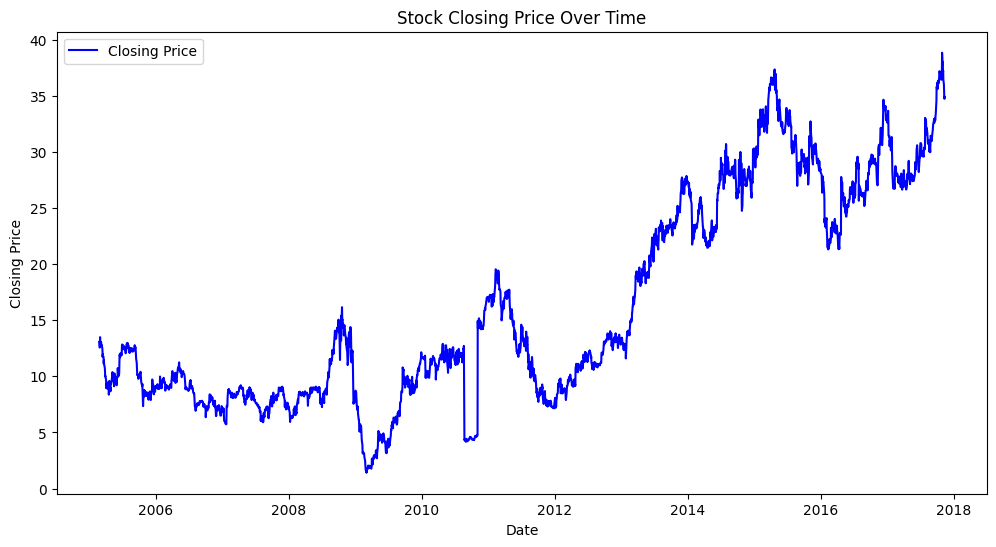

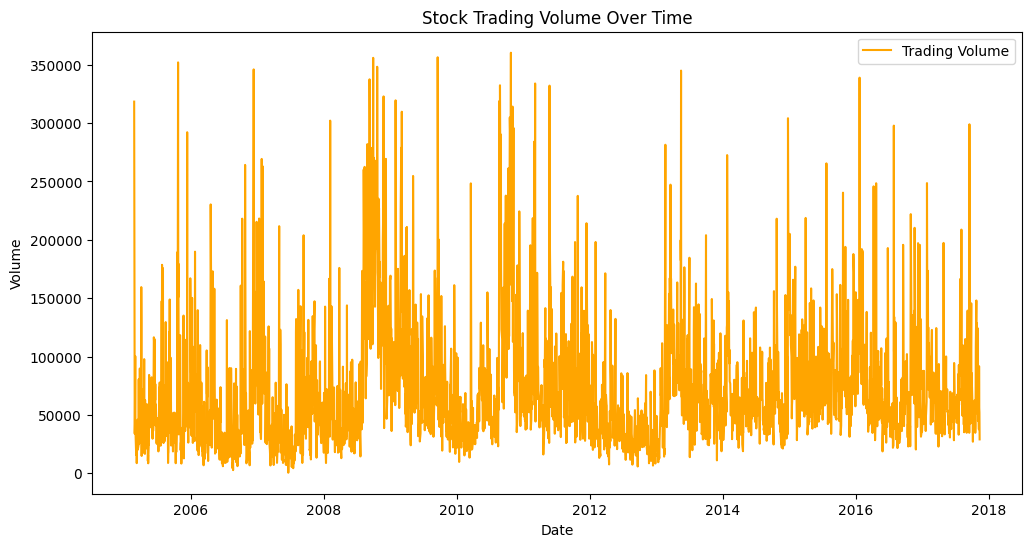

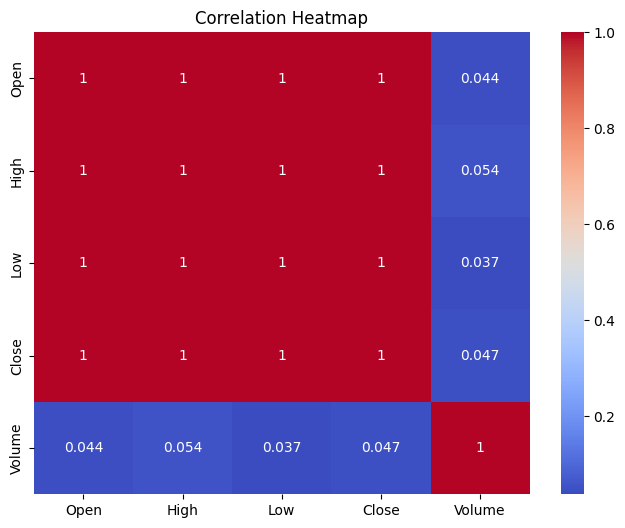

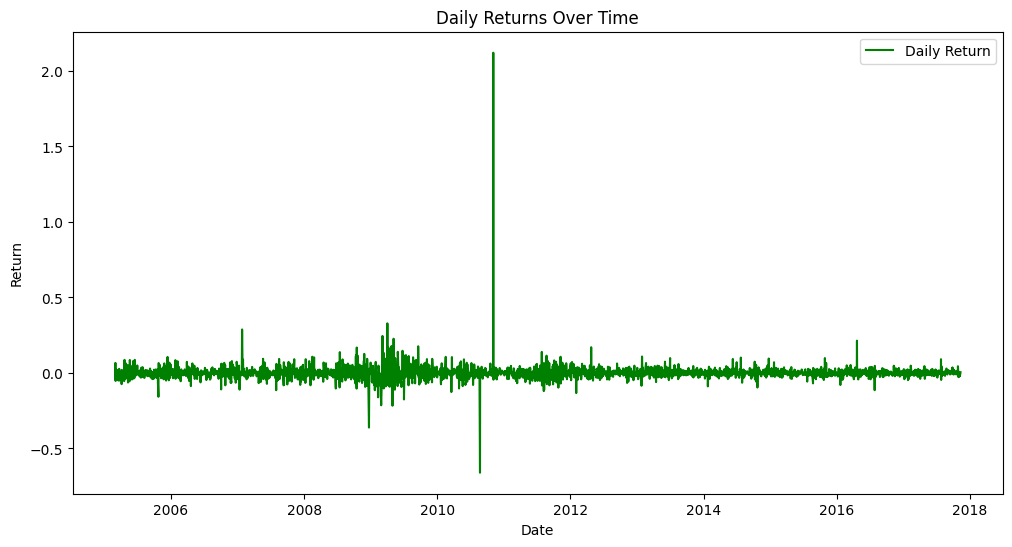

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


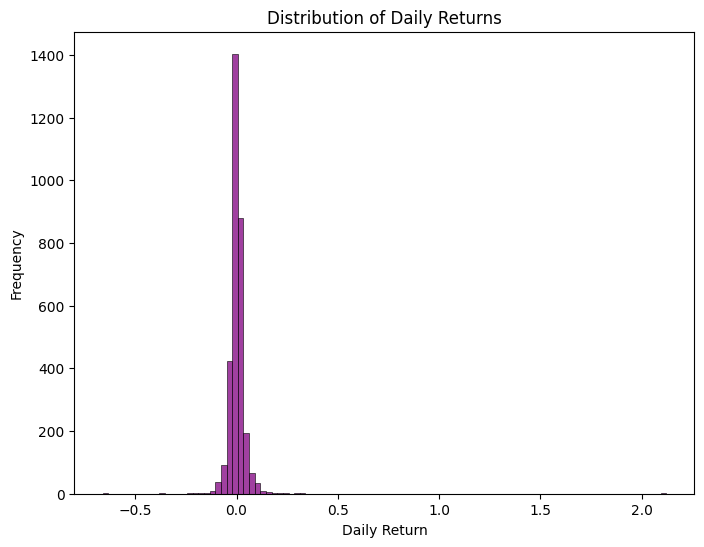

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic info about dataset
print("Dataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

# 2. Closing price trend
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

# 3. Volume trend
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'], label='Trading Volume', color='orange')
plt.title('Stock Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 5. Daily returns
df['Daily Return'] = df['Close'].pct_change()
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Daily Return'], label='Daily Return', color='green')
plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.show()

# 6. Histogram of daily returns
plt.figure(figsize=(8,6))
sns.histplot(df['Daily Return'].dropna(), bins=100, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


In [14]:
import numpy as np
import pandas as pd

def add_features(df):
    df = df.copy()
    df.set_index("Date", inplace=True)

    # Moving Averages
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

    # Bollinger Bands
    df['20_SMA'] = df['Close'].rolling(window=20).mean()
    df['20_STD'] = df['Close'].rolling(window=20).std()
    df['BB_upper'] = df['20_SMA'] + (df['20_STD'] * 2)
    df['BB_lower'] = df['20_SMA'] - (df['20_STD'] * 2)

    # RSI
    delta = df['Close'].diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain, index=df.index).rolling(window=14).mean()
    avg_loss = pd.Series(loss, index=df.index).rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    EMA_12 = df['Close'].ewm(span=12, adjust=False).mean()
    EMA_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = EMA_12 - EMA_26
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # Lag Features
    df['Lag_1'] = df['Close'].shift(1)
    df['Lag_2'] = df['Close'].shift(2)
    df['Lag_Volume'] = df['Volume'].shift(1)

    # Rolling Statistics
    df['Rolling_Mean_7'] = df['Close'].rolling(window=7).mean()
    df['Rolling_Std_7'] = df['Close'].rolling(window=7).std()
    df['Rolling_Volatility_7'] = df['Close'].pct_change().rolling(window=7).std()

    # Drop NaN values
    df.dropna(inplace=True)

    return df

# Apply to stocks and ETFs
stocks_features = add_features(stocks_df)
etfs_features = add_features(etfs_df)

print("Stocks with features:", stocks_features.shape)
print("ETFs with features:", etfs_features.shape)


Stocks with features: (14883749, 24)
ETFs with features: (2565473, 24)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. Define features and target
# ==============================
# Stocks
X_stocks = stocks_features.drop(columns=['Close'])
y_stocks = stocks_features['Close']

# ETFs
X_etfs = etfs_features.drop(columns=['Close'])
y_etfs = etfs_features['Close']

# Keep only numeric columns
X_stocks = X_stocks.select_dtypes(include=[np.number])
X_etfs = X_etfs.select_dtypes(include=[np.number])

# ==============================
# 2. Train/Test Split
# ==============================
X_train_stocks, X_test_stocks, y_train_stocks, y_test_stocks = train_test_split(
    X_stocks, y_stocks, test_size=0.2, shuffle=False
)

X_train_etfs, X_test_etfs, y_train_etfs, y_test_etfs = train_test_split(
    X_etfs, y_etfs, test_size=0.2, shuffle=False
)

# ==============================
# 3. Feature Scaling
# ==============================
scaler_stocks = StandardScaler()
X_train_stocks_scaled = scaler_stocks.fit_transform(X_train_stocks)
X_test_stocks_scaled = scaler_stocks.transform(X_test_stocks)

scaler_etfs = StandardScaler()
X_train_etfs_scaled = scaler_etfs.fit_transform(X_train_etfs)
X_test_etfs_scaled = scaler_etfs.transform(X_test_etfs)

# ==============================
# 4. Shapes check
# ==============================
print("Stocks Train:", X_train_stocks_scaled.shape, y_train_stocks.shape)
print("Stocks Test :", X_test_stocks_scaled.shape, y_test_stocks.shape)
print("ETFs Train :", X_train_etfs_scaled.shape, y_train_etfs.shape)
print("ETFs Test  :", X_test_etfs_scaled.shape, y_test_etfs.shape)

Stocks Train: (11906999, 22) (11906999,)
Stocks Test : (2976750, 22) (2976750,)
ETFs Train : (2052378, 22) (2052378,)
ETFs Test  : (513095, 22) (513095,)


In [16]:
import tensorflow as tf
print("TF version:", tf.__version__)
!ldd /usr/local/lib/python3.*/dist-packages/tensorflow/python/_pywrap_tensorflow_internal.so | grep cudnn


TF version: 2.18.0


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==============================
# 1. Build Model
# ==============================
model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train_stocks_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # regression output
])

# ==============================
# 2. Compile Model
# ==============================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",      # mean squared error
    metrics=["mae"]  # mean absolute error
)

# ==============================
# 3. Train Model
# ==============================
history = model.fit(
    X_train_stocks_scaled, y_train_stocks,
    validation_data=(X_test_stocks_scaled, y_test_stocks),
    epochs=10,            # start small, tune later
    batch_size=1024,      # reduce if memory issues
    verbose=1
)

# ==============================
# 4. Evaluate
# ==============================
y_pred = model.predict(X_test_stocks_scaled).flatten()
mse = mean_squared_error(y_test_stocks, y_pred)
mae = mean_absolute_error(y_test_stocks, y_pred)
r2 = r2_score(y_test_stocks, y_pred)

print(f"\nTest MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# ==============================
# 5. Save Model
# ==============================
model.save("deep_learning_stocks.h5")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-19 14:39:46.683828: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 89s 7ms/step - loss: 14314360537088.0000 - mae: 45467.2812 - val_loss: 6461386.0000 - val_mae: 666.0755
Epoch 2/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 85s 7ms/step - loss: 299846500352.0000 - mae: 4565.5654 - val_loss: 22404970.0000 - val_mae: 847.3984
Epoch 3/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 199854473216.0000 - mae: 3995.9236 - val_loss: 5350829.5000 - val_mae: 952.3661
Epoch 4/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 273774067712.0000 - mae: 4836.4121 - val_loss: 1784803.5000 - val_mae: 724.5505
Epoch 5/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - loss: 285712875520.0000 - mae: 4866.2305 - val_loss: 415737.5625 - val_mae: 411.1345
Epoch 6/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 86s 7ms/step - loss: 308349206528.0000 - mae: 4393.1294 - val_loss: 302915.2812 - val_mae: 289.5726
Epoch 7/10
11628/11628 ━━━━━━━━━━━━━━━━━━━━ 88s 7ms/step - loss: 263990525952.0000 - mae: 4107.6479 - val_loss: 308826.0312 - va